In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# from cinplaAnalysis.utils import *
import quantities as pq

%matplotlib inline

In [2]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/icsd.py:1158: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if f_type is not 'identity' and f_order is None:


In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [202]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-0.1,vmax=.1)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    im = ax.imshow(np.array(csd), origin='lower', vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [174]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = .277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = .277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high

    

In [175]:
def produce_iCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high, icsd_low, icsd_low_half, icsd_low_quarter

In [176]:
def produce_sCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)
    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high_std

In [216]:
def produce_sCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'sigma_top':sigma_top,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam
    }
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }
    
    std_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }

    
    icsd_high_std = StandardCSD(**std_input_high)
    icsd_low_std = StandardCSD(**std_input_low)
    icsd_low_half_std = StandardCSD(**std_input_low_half)
    icsd_low_quarter_std = StandardCSD(**std_input_low_quarter)

    return icsd_high_std, icsd_low_std, icsd_low_half_std, icsd_low_quarter_std

In [177]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    # objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    # objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    # objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    # for l in range(objective_disk_full_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
    #     elif l == objective_disk_full_lowRes.shape[1]-1:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
    #     else:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    # for l in range(objective_disk_half_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    #     elif l == objective_disk_half_lowRes.shape[1]-1:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    # for l in range(objective_disk_quarter_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    #     elif l == objective_disk_quarter_lowRes.shape[1]-1:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes

In [178]:
def produce_oCSD_all(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [223]:
nncsd.shape

(50, 99)

In [227]:
def produce_nnCSD_all(data):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    objective_disk_full_highRes = data # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros((data.shape[0],data.shape[1]//2))
    objective_disk_half_lowRes = np.zeros((data.shape[0],objective_disk_full_lowRes.shape[1]//2))
    objective_disk_quarter_lowRes = np.zeros((data.shape[0],objective_disk_half_lowRes.shape[1]//2))
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [11]:
highResRerun = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/total.npy')
highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550]

In [12]:
original_csd = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]

In [13]:
highResOriginal.shape

(50, 304)

In [14]:
lfpIdx = np.arange(101)
csd500Idx = np.arange(101,202)
csd200Idx = np.arange(202,303)
csd50Idx = np.arange(303,404)
csd100Idx = np.arange(404,505)
csd20Idx = np.arange(505,606)

In [15]:
icsd_high_new_500, icsd_low_new_500, icsd_half_new_500, icsd_quarter_new_500 = produce_iCSD_all(highResRerun,lfpIdx,1000e-6*pq.m)
icsd_high_new_200, icsd_low_new_200, icsd_half_new_200, icsd_quarter_new_200 = produce_iCSD_all(highResRerun,lfpIdx,400e-6*pq.m)
icsd_high_new_100, icsd_low_new_100, icsd_half_new_100, icsd_quarter_new_100 = produce_iCSD_all(highResRerun,lfpIdx,200e-6*pq.m)
icsd_high_new_50, icsd_low_new_50, icsd_half_new_50, icsd_quarter_new_50 = produce_iCSD_all(highResRerun,lfpIdx,100e-6*pq.m)
icsd_high_new_20, icsd_low_new_20, icsd_half_new_20, icsd_quarter_new_20 = produce_iCSD_all(highResRerun,lfpIdx,40e-6*pq.m)

In [217]:
sCsd_high_new, sCsd_low_new, sCsd_half_new, sCsd_quarter_new = produce_sCSD_all(highResRerun,lfpIdx,40E-6 * pq.m)

In [17]:
ocsd_500, ocsd_low_500, ocsd_half_500, ocsd_quarter_500 = produce_oCSD_all(highResRerun,lfpIdx,csd500Idx)
ocsd_20, ocsd_low_20, ocsd_half_20, ocsd_quarter_20 = produce_oCSD_all(highResRerun,lfpIdx,csd20Idx)
ocsd_200, ocsd_low_200, ocsd_half_200, ocsd_quarter_200 = produce_oCSD_all(highResRerun,lfpIdx,csd200Idx)
ocsd_100, ocsd_low_100, ocsd_half_100, ocsd_quarter_100 = produce_oCSD_all(highResRerun,lfpIdx,csd100Idx)
ocsd_50, ocsd_low_50, ocsd_half_50, ocsd_quarter_50 = produce_oCSD_all(highResRerun,lfpIdx,csd50Idx)


In [18]:
icsd_20_original = produce_iCSD(highResOriginal,lfpIdx,40e-6*pq.m)

In [19]:
icsd_100_original = produce_iCSD(highResOriginal,lfpIdx,200e-6*pq.m)

In [20]:
ocsd_20_original= produce_oCSD(original_csd,lfpIdx,np.arange(303,404))

In [21]:
ocsd_100_original= produce_oCSD(original_csd,lfpIdx,np.arange(101,202))

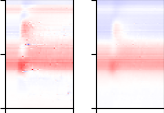

In [36]:
fig, axes = plt.subplots(1,2,figsize=(2,1.5))
plotFig(axes[0],icsd_high_new_20.get_csd())
plotFig(axes[1],icsd_20_original.get_csd())
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/originalVsNew20.png',dpi=600)

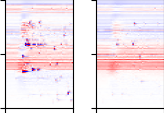

In [22]:
fig, axes = plt.subplots(1,2,figsize=(2,1.5))
plotFig(axes[0],icsd_high_new_100.get_csd())
plotFig(axes[1],icsd_100_original.get_csd())
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/originalVsNew100.png',dpi=600)

In [233]:
nncsd = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_nncsd/total.npy') # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um


In [234]:
nncsd, nncsd_low, nncsd_half, nncsd_quarter = produce_nnCSD_all(nncsd)

In [239]:
nncsd_quarter.shape

(50, 12)

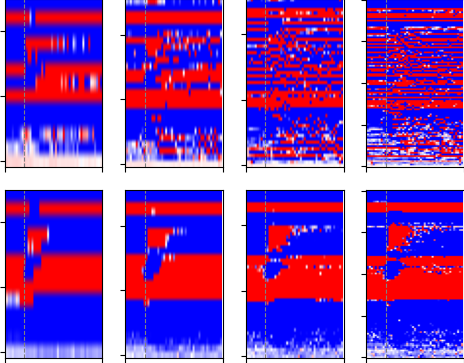

In [198]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_500.get_csd())
plotFig(axes[0][1],icsd_half_new_500.get_csd())
plotFig(axes[0][2],icsd_low_new_500.get_csd())
plotFig(axes[0][3],icsd_high_new_500.get_csd())

plotFig(axes[1][0],ocsd_quarter_500.T)
plotFig(axes[1][1],ocsd_half_500.T)
plotFig(axes[1][2],ocsd_low_500.T)
plotFig(axes[1][3],ocsd_500.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

# plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_Realigned.png',dpi=600)

In [172]:
normalized_2d_correlation(icsd_high_new_500.get_csd().magnitude,ocsd_500.T)

np.float64(0.2620864857919108)

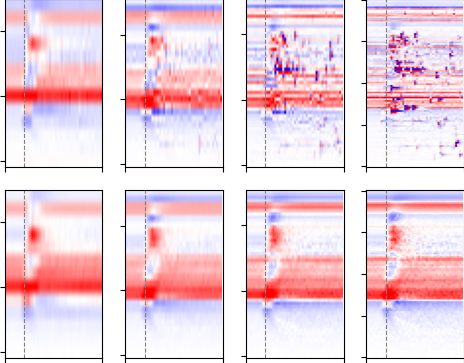

In [182]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_200.get_csd())
plotFig(axes[0][1],icsd_half_new_200.get_csd())
plotFig(axes[0][2],icsd_low_new_200.get_csd())
plotFig(axes[0][3],icsd_high_new_200.get_csd())

plotFig(axes[1][0],ocsd_quarter_200.T)
plotFig(axes[1][1],ocsd_half_200.T)
plotFig(axes[1][2],ocsd_low_200.T)
plotFig(axes[1][3],ocsd_200.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

# plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_Realigned_200.png',dpi=600)

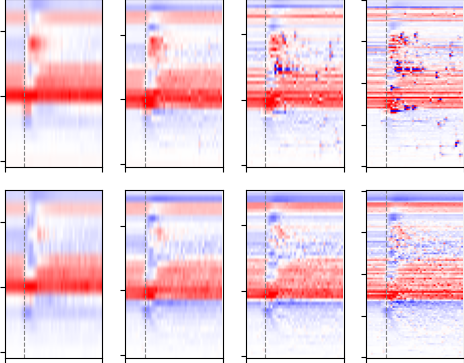

In [183]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_100.get_csd())
plotFig(axes[0][1],icsd_half_new_100.get_csd())
plotFig(axes[0][2],icsd_low_new_100.get_csd())
plotFig(axes[0][3],icsd_high_new_100.get_csd())

plotFig(axes[1][0],ocsd_quarter_100.T)
plotFig(axes[1][1],ocsd_half_100.T)
plotFig(axes[1][2],ocsd_low_100.T)
plotFig(axes[1][3],ocsd_100.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

# plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_Realigned_100.png',dpi=600)

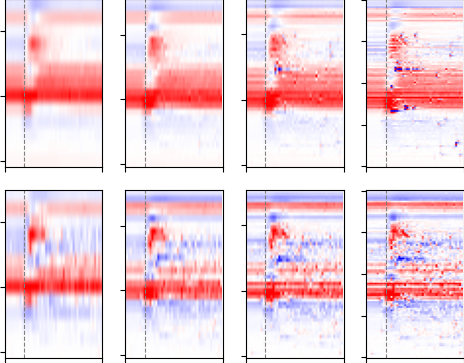

In [184]:
fig, axes = plt.subplots(2,4,figsize=(5,4))

plotFig(axes[0][0],icsd_quarter_new_50.get_csd())
plotFig(axes[0][1],icsd_half_new_50.get_csd())
plotFig(axes[0][2],icsd_low_new_50.get_csd())
plotFig(axes[0][3],icsd_high_new_50.get_csd())

plotFig(axes[1][0],ocsd_quarter_50.T)
plotFig(axes[1][1],ocsd_half_50.T)
plotFig(axes[1][2],ocsd_low_50.T)
plotFig(axes[1][3],ocsd_50.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

# plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_Realigned_50.png',dpi=600)

In [22]:
correlations_high = []
correlations_low = []
correlations_half = []
correlations_quarter = []

for i in np.arange(50):
    correlations_high.append(np.corrcoef(icsd_high_new_500.get_csd()[:,i],ocsd_500.T[:,i])[0,1])
    correlations_low.append(np.corrcoef(icsd_low_new_500.get_csd()[:,i],ocsd_low_500.T[:,i])[0,1])
    correlations_half.append(np.corrcoef(icsd_half_new_500.get_csd()[:,i],ocsd_half_500.T[:,i])[0,1])
    correlations_quarter.append(np.corrcoef(icsd_quarter_new_500.get_csd()[:,i],ocsd_quarter_500.T[:,i])[0,1])


In [23]:
correlations_high_200 = []
correlations_low_200 = []
correlations_half_200 = []
correlations_quarter_200 = []

for i in np.arange(50):
    correlations_high_200.append(np.corrcoef(icsd_high_new_200.get_csd()[:,i],ocsd_200.T[:,i])[0,1])
    correlations_low_200.append(np.corrcoef(icsd_low_new_200.get_csd()[:,i],ocsd_low_200.T[:,i])[0,1])
    correlations_half_200.append(np.corrcoef(icsd_half_new_200.get_csd()[:,i],ocsd_half_200.T[:,i])[0,1])
    correlations_quarter_200.append(np.corrcoef(icsd_quarter_new_200.get_csd()[:,i],ocsd_quarter_200.T[:,i])[0,1])

In [24]:
correlations_high_100 = []
correlations_low_100 = []
correlations_half_100 = []
correlations_quarter_100 = []

for i in np.arange(50):
    correlations_high_100.append(np.corrcoef(icsd_high_new_100.get_csd()[:,i],ocsd_100.T[:,i])[0,1])
    correlations_low_100.append(np.corrcoef(icsd_low_new_100.get_csd()[:,i],ocsd_low_100.T[:,i])[0,1])
    correlations_half_100.append(np.corrcoef(icsd_half_new_100.get_csd()[:,i],ocsd_half_100.T[:,i])[0,1])
    correlations_quarter_100.append(np.corrcoef(icsd_quarter_new_100.get_csd()[:,i],ocsd_quarter_100.T[:,i])[0,1])

In [25]:
correlations_high_50 = []
correlations_low_50 = []
correlations_half_50 = []
correlations_quarter_50 = []

for i in np.arange(50):
    correlations_high_50.append(np.corrcoef(icsd_high_new_50.get_csd()[:,i],ocsd_50.T[:,i])[0,1])
    correlations_low_50.append(np.corrcoef(icsd_low_new_50.get_csd()[:,i],ocsd_low_50.T[:,i])[0,1])
    correlations_half_50.append(np.corrcoef(icsd_half_new_50.get_csd()[:,i],ocsd_half_50.T[:,i])[0,1])
    correlations_quarter_50.append(np.corrcoef(icsd_quarter_new_50.get_csd()[:,i],ocsd_quarter_50.T[:,i])[0,1])

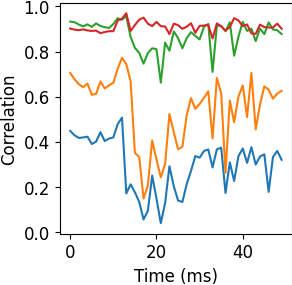

In [26]:
plt.figure(figsize=(3,3))
plt.plot(correlations_high)
plt.plot(correlations_low)
plt.plot(correlations_half)
plt.plot(correlations_quarter)

plt.xlabel('Time (ms)')
plt.ylabel('Correlation')

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_correlation_Realigned.png',dpi=600)

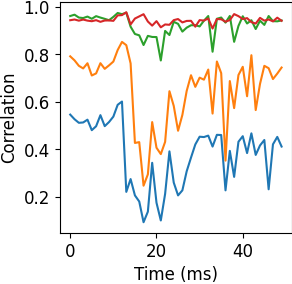

In [33]:
plt.figure(figsize=(3,3))
plt.plot(correlations_high_200)
plt.plot(correlations_low_200)
plt.plot(correlations_half_200)
plt.plot(correlations_quarter_200)

plt.xlabel('Time (ms)')
plt.ylabel('Correlation')

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_correlation_Realigned_200.png',dpi=600)

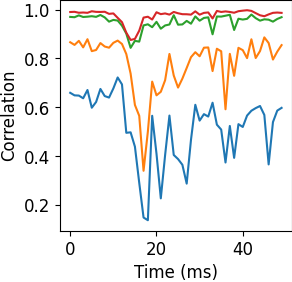

In [34]:
plt.figure(figsize=(3,3))
plt.plot(correlations_high_100)
plt.plot(correlations_low_100)
plt.plot(correlations_half_100)
plt.plot(correlations_quarter_100)

plt.xlabel('Time (ms)')
plt.ylabel('Correlation')

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_correlation_Realigned_100.png',dpi=600)

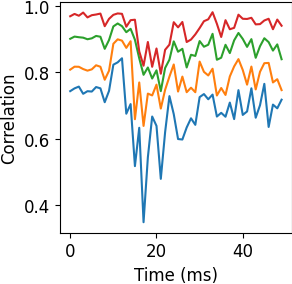

In [35]:
plt.figure(figsize=(3,3))
plt.plot(correlations_high_50)
plt.plot(correlations_low_50)
plt.plot(correlations_half_50)
plt.plot(correlations_quarter_50)

plt.xlabel('Time (ms)')
plt.ylabel('Correlation')

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/csdBySpacing_correlation_Realigned_50.png',dpi=600)

In [204]:
from scipy.signal import correlate2d

def normalized_2d_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)/np.mean(np.sqrt(a**2))
    b = b.astype(float)/np.mean(np.sqrt(b**2))
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den
    
correlation2d_20 = normalized_2d_correlation(icsd_high_new_20.get_csd().magnitude,ocsd_20.T)
correlation2d_50 = normalized_2d_correlation(icsd_high_new_50.get_csd().magnitude,ocsd_50.T)
correlation2d_100 = normalized_2d_correlation(icsd_high_new_100.get_csd().magnitude,ocsd_100.T)
correlation2d_200 = normalized_2d_correlation(icsd_high_new_200.get_csd().magnitude,ocsd_200.T)
correlation2d_500 = normalized_2d_correlation(icsd_high_new_500.get_csd().magnitude,ocsd_500.T)

correlation2d_std_20 = normalized_2d_correlation(sCsd_high_new.get_csd().magnitude,ocsd_20.T)
correlation2d_std_50 = normalized_2d_correlation(sCsd_high_new.get_csd().magnitude,ocsd_50.T)
correlation2d_std_100 = normalized_2d_correlation(sCsd_high_new.get_csd().magnitude,ocsd_100.T)
correlation2d_std_200 = normalized_2d_correlation(sCsd_high_new.get_csd().magnitude,ocsd_200.T)
correlation2d_std_500 = normalized_2d_correlation(sCsd_high_new.get_csd().magnitude,ocsd_500.T)

correlation2d_nn_20 = normalized_2d_correlation(nncsd.T,ocsd_20.T[1:-1])
correlation2d_nn_50 = normalized_2d_correlation(nncsd.T,ocsd_50.T[1:-1])
correlation2d_nn_100 = normalized_2d_correlation(nncsd.T,ocsd_100.T[1:-1])
correlation2d_nn_200 = normalized_2d_correlation(nncsd.T,ocsd_200.T[1:-1])
correlation2d_nn_500 = normalized_2d_correlation(nncsd.T,ocsd_500.T[1:-1])

In [243]:
from scipy.signal import correlate2d

def normalized_2d_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)/np.mean(np.sqrt(a**2))
    b = b.astype(float)/np.mean(np.sqrt(b**2))
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den
    
correlation2d_20_low = normalized_2d_correlation(icsd_low_new_20.get_csd().magnitude,ocsd_low_20.T)
correlation2d_50_low = normalized_2d_correlation(icsd_low_new_50.get_csd().magnitude,ocsd_low_50.T)
correlation2d_100_low = normalized_2d_correlation(icsd_low_new_100.get_csd().magnitude,ocsd_low_100.T)
correlation2d_200_low = normalized_2d_correlation(icsd_low_new_200.get_csd().magnitude,ocsd_low_200.T)
correlation2d_500_low = normalized_2d_correlation(icsd_low_new_500.get_csd().magnitude,ocsd_low_500.T)

correlation2d_std_20_low = normalized_2d_correlation(sCsd_low_new.get_csd().magnitude,ocsd_low_20.T)
correlation2d_std_50_low = normalized_2d_correlation(sCsd_low_new.get_csd().magnitude,ocsd_low_50.T)
correlation2d_std_100_low = normalized_2d_correlation(sCsd_low_new.get_csd().magnitude,ocsd_low_100.T)
correlation2d_std_200_low = normalized_2d_correlation(sCsd_low_new.get_csd().magnitude,ocsd_low_200.T)
correlation2d_std_500_low = normalized_2d_correlation(sCsd_low_new.get_csd().magnitude,ocsd_low_500.T)

correlation2d_nn_20_low = normalized_2d_correlation(nncsd_low.T,ocsd_low_20.T[1:-1])
correlation2d_nn_50_low = normalized_2d_correlation(nncsd_low.T,ocsd_low_50.T[1:-1])
correlation2d_nn_100_low = normalized_2d_correlation(nncsd_low.T,ocsd_low_100.T[1:-1])
correlation2d_nn_200_low = normalized_2d_correlation(nncsd_low.T,ocsd_low_200.T[1:-1])
correlation2d_nn_500_low = normalized_2d_correlation(nncsd_low.T,ocsd_low_500.T[1:-1])

In [247]:
from scipy.signal import correlate2d

def normalized_2d_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)/np.mean(np.sqrt(a**2))
    b = b.astype(float)/np.mean(np.sqrt(b**2))
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den
    
correlation2d_20_half = normalized_2d_correlation(icsd_half_new_20.get_csd().magnitude,ocsd_half_20.T)
correlation2d_50_half = normalized_2d_correlation(icsd_half_new_50.get_csd().magnitude,ocsd_half_50.T)
correlation2d_100_half = normalized_2d_correlation(icsd_half_new_100.get_csd().magnitude,ocsd_half_100.T)
correlation2d_200_half = normalized_2d_correlation(icsd_half_new_200.get_csd().magnitude,ocsd_half_200.T)
correlation2d_500_half = normalized_2d_correlation(icsd_half_new_500.get_csd().magnitude,ocsd_half_500.T)

correlation2d_std_20_half = normalized_2d_correlation(sCsd_half_new.get_csd().magnitude,ocsd_half_20.T)
correlation2d_std_50_half = normalized_2d_correlation(sCsd_half_new.get_csd().magnitude,ocsd_half_50.T)
correlation2d_std_100_half = normalized_2d_correlation(sCsd_half_new.get_csd().magnitude,ocsd_half_100.T)
correlation2d_std_200_half = normalized_2d_correlation(sCsd_half_new.get_csd().magnitude,ocsd_half_200.T)
correlation2d_std_500_half = normalized_2d_correlation(sCsd_half_new.get_csd().magnitude,ocsd_half_500.T)

correlation2d_nn_20_half = normalized_2d_correlation(nncsd_half.T,ocsd_half_20.T[1:-1])
correlation2d_nn_50_half = normalized_2d_correlation(nncsd_half.T,ocsd_half_50.T[1:-1])
correlation2d_nn_100_half = normalized_2d_correlation(nncsd_half.T,ocsd_half_100.T[1:-1])
correlation2d_nn_200_half = normalized_2d_correlation(nncsd_half.T,ocsd_half_200.T[1:-1])
correlation2d_nn_500_half = normalized_2d_correlation(nncsd_half.T,ocsd_half_500.T[1:-1])

In [253]:
from scipy.signal import correlate2d

def normalized_2d_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)/np.mean(np.sqrt(a**2))
    b = b.astype(float)/np.mean(np.sqrt(b**2))
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den
    
correlation2d_20_quarter = normalized_2d_correlation(icsd_quarter_new_20.get_csd().magnitude,ocsd_quarter_20.T)
correlation2d_50_quarter = normalized_2d_correlation(icsd_quarter_new_50.get_csd().magnitude,ocsd_quarter_50.T)
correlation2d_100_quarter = normalized_2d_correlation(icsd_quarter_new_100.get_csd().magnitude,ocsd_quarter_100.T)
correlation2d_200_quarter = normalized_2d_correlation(icsd_quarter_new_200.get_csd().magnitude,ocsd_quarter_200.T)
correlation2d_500_quarter = normalized_2d_correlation(icsd_quarter_new_500.get_csd().magnitude,ocsd_quarter_500.T)

correlation2d_std_20_quarter = normalized_2d_correlation(sCsd_quarter_new.get_csd().magnitude,ocsd_quarter_20.T)
correlation2d_std_50_quarter = normalized_2d_correlation(sCsd_quarter_new.get_csd().magnitude,ocsd_quarter_50.T)
correlation2d_std_100_quarter = normalized_2d_correlation(sCsd_quarter_new.get_csd().magnitude,ocsd_quarter_100.T)
correlation2d_std_200_quarter = normalized_2d_correlation(sCsd_quarter_new.get_csd().magnitude,ocsd_quarter_200.T)
correlation2d_std_500_quarter = normalized_2d_correlation(sCsd_quarter_new.get_csd().magnitude,ocsd_quarter_500.T)

correlation2d_nn_20_quarter = normalized_2d_correlation(nncsd_quarter.T,ocsd_quarter_20.T[1:])
correlation2d_nn_50_quarter = normalized_2d_correlation(nncsd_quarter.T,ocsd_quarter_50.T[1:])
correlation2d_nn_100_quarter = normalized_2d_correlation(nncsd_quarter.T,ocsd_quarter_100.T[1:])
correlation2d_nn_200_quarter = normalized_2d_correlation(nncsd_quarter.T,ocsd_quarter_200.T[1:])
correlation2d_nn_500_quarter = normalized_2d_correlation(nncsd_quarter.T,ocsd_quarter_500.T[1:])

In [219]:
ocsd_low_20.shape

(50, 51)

In [194]:
normalized_2d_correlation(icsd_high_new_50.get_csd().magnitude,ocsd_50.T)

np.float64(0.6739112594459086)

In [195]:
normalized_2d_correlation(nncsd.T,ocsd_50.T[1:-1])

np.float64(0.6846494412638662)

In [125]:
icsd_high_new_20.get_csd().magnitude

array([[-34.34082961, -36.04864307, -34.42937187, ..., -48.8959289 ,
        -57.96608057, -52.54992256],
       [-30.48489265, -31.38320991, -29.1835651 , ..., -40.20487515,
        -51.47515324, -41.64717066],
       [-28.20555047, -29.91781741, -27.63111384, ..., -31.38057202,
        -60.75683455, -34.86093822],
       ...,
       [172.87063328, 170.81023778, 174.27377453, ..., 160.89430473,
        141.12305685, 155.96653338],
       [149.87271987, 147.33984631, 151.10781863, ..., 138.99050439,
        118.22687181, 132.63842873],
       [238.45904878, 232.45981291, 240.11552972, ..., 201.33162223,
        156.41112419, 187.71656061]], shape=(101, 50))

In [206]:
corrIcsd = [correlation2d_200,correlation2d_100,correlation2d_50,correlation2d_20]
corrScsd = [correlation2d_std_200,correlation2d_std_100,correlation2d_std_50,correlation2d_std_20]
corrNcsd = [correlation2d_nn_200,correlation2d_nn_100,correlation2d_nn_50,correlation2d_nn_20]

In [244]:
corrIcsd = [correlation2d_200_low,correlation2d_100_low,correlation2d_50_low,correlation2d_20_low]
corrScsd = [correlation2d_std_200_low,correlation2d_std_100_low,correlation2d_std_50_low,correlation2d_std_20_low]
corrNcsd = [correlation2d_nn_200_low,correlation2d_nn_100_low,correlation2d_nn_50_low,correlation2d_nn_20_low]

In [248]:
corrIcsd = [correlation2d_200_half,correlation2d_100_half,correlation2d_50_half,correlation2d_20_half]
corrScsd = [correlation2d_std_200_half,correlation2d_std_100_half,correlation2d_std_50_half,correlation2d_std_20_half]
corrNcsd = [correlation2d_nn_200_half,correlation2d_nn_100_half,correlation2d_nn_50_half,correlation2d_nn_20_half]

In [254]:
corrIcsd = [correlation2d_200_quarter,correlation2d_100_quarter,correlation2d_50_quarter,correlation2d_20_quarter]
corrScsd = [correlation2d_std_200_quarter,correlation2d_std_100_quarter,correlation2d_std_50_quarter,correlation2d_std_20_quarter]
corrNcsd = [correlation2d_nn_200_quarter,correlation2d_nn_100_quarter,correlation2d_nn_50_quarter,correlation2d_nn_20_quarter]

In [207]:
print(corrIcsd)
print(corrScsd)
print(corrNcsd)

[np.float64(0.2737025997611516), np.float64(0.42867241502686915), np.float64(0.6610438157597407), np.float64(0.43435995540116956)]
[np.float64(0.29620819864453063), np.float64(0.3153933617843697), np.float64(0.4282106230431804), np.float64(0.6982635808488439)]
[np.float64(0.5722405462555558), np.float64(0.5234779289050037), np.float64(0.6219816877828916), np.float64(0.739094507840738)]


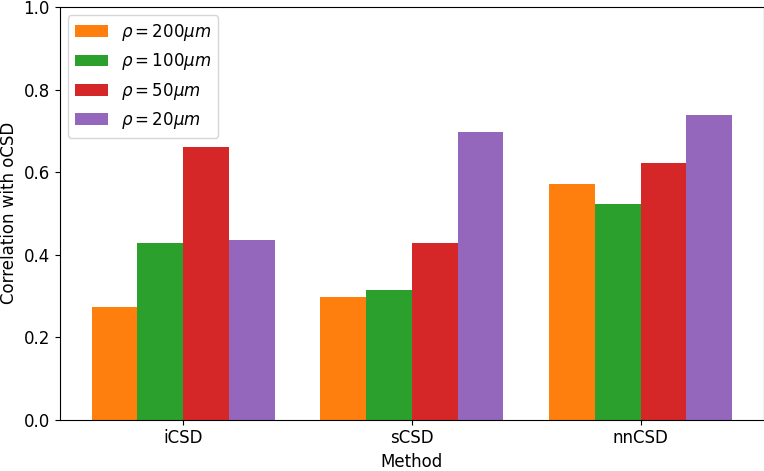

<Figure size 640x480 with 0 Axes>

In [208]:
labels = ['iCSD', 'sCSD', 'nnCSD']
data = [corrIcsd, corrScsd, corrNcsd]

radii = [200, 100, 50, 20]
colors = ['C1', 'C2', 'C3', 'C4']

x = np.arange(len(labels))
n_bars = len(radii)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(8, 5))

for i, (radius, color) in enumerate(zip(radii, colors)):
    offsets = x + (i - n_bars / 2 + 0.5) * width
    values = [group[i] for group in data]  # unwrap [[scalar]] -> scalar
    ax.bar(offsets, values, width=width, label=rf'$\rho={radius}\mu m$', color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Method')
ax.set_ylabel('Correlation with oCSD')
ax.legend()
plt.tight_layout()
plt.ylim([0,1])
plt.show()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/correlation_radii_bar.png',dpi=600)

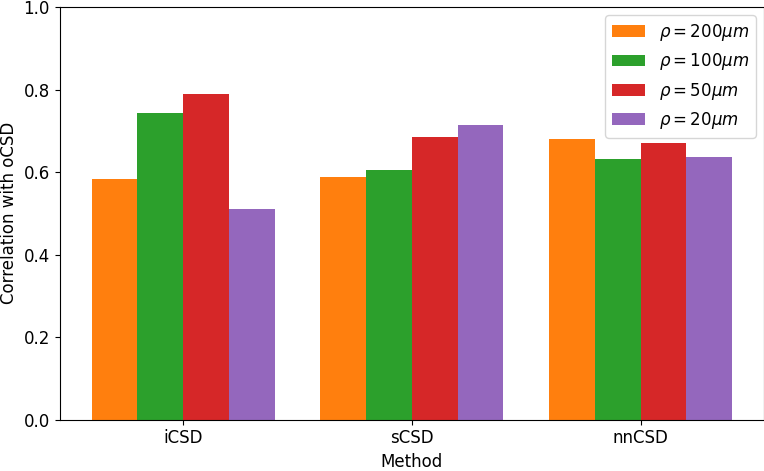

In [245]:
labels = ['iCSD', 'sCSD', 'nnCSD']
data = [corrIcsd, corrScsd, corrNcsd]

radii = [200, 100, 50, 20]
colors = ['C1', 'C2', 'C3', 'C4']

x = np.arange(len(labels))
n_bars = len(radii)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(8, 5))

for i, (radius, color) in enumerate(zip(radii, colors)):
    offsets = x + (i - n_bars / 2 + 0.5) * width
    values = [group[i] for group in data]  # unwrap [[scalar]] -> scalar
    ax.bar(offsets, values, width=width, label=rf'$\rho={radius}\mu m$', color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Method')
ax.set_ylabel('Correlation with oCSD')
ax.legend()
plt.tight_layout()
plt.ylim([0,1])
plt.show()

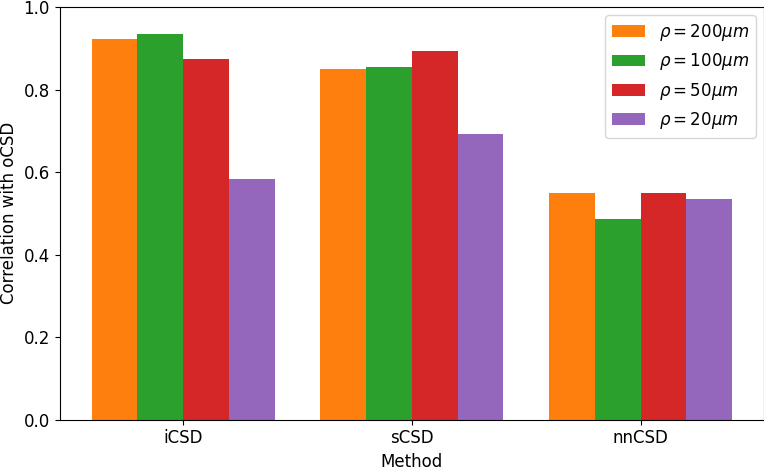

In [249]:
labels = ['iCSD', 'sCSD', 'nnCSD']
data = [corrIcsd, corrScsd, corrNcsd]

radii = [200, 100, 50, 20]
colors = ['C1', 'C2', 'C3', 'C4']

x = np.arange(len(labels))
n_bars = len(radii)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(8, 5))

for i, (radius, color) in enumerate(zip(radii, colors)):
    offsets = x + (i - n_bars / 2 + 0.5) * width
    values = [group[i] for group in data]  # unwrap [[scalar]] -> scalar
    ax.bar(offsets, values, width=width, label=rf'$\rho={radius}\mu m$', color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Method')
ax.set_ylabel('Correlation with oCSD')
ax.legend()
plt.tight_layout()
plt.ylim([0,1])
plt.show()

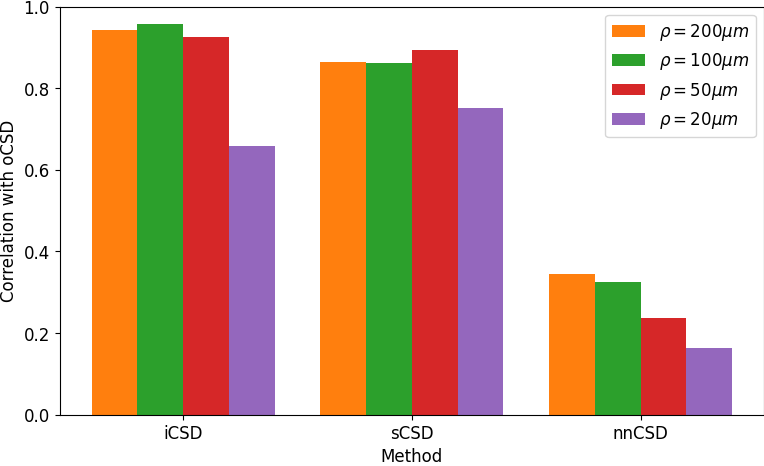

In [255]:
labels = ['iCSD', 'sCSD', 'nnCSD']
data = [corrIcsd, corrScsd, corrNcsd]

radii = [200, 100, 50, 20]
colors = ['C1', 'C2', 'C3', 'C4']

x = np.arange(len(labels))
n_bars = len(radii)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(8, 5))

for i, (radius, color) in enumerate(zip(radii, colors)):
    offsets = x + (i - n_bars / 2 + 0.5) * width
    values = [group[i] for group in data]  # unwrap [[scalar]] -> scalar
    ax.bar(offsets, values, width=width, label=rf'$\rho={radius}\mu m$', color=color)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Method')
ax.set_ylabel('Correlation with oCSD')
ax.legend()
plt.tight_layout()
plt.ylim([0,1])
plt.show()

In [62]:
print([correlation2d_20,correlation2d_50,correlation2d_100,correlation2d_200])
print([correlation2d_std_20,correlation2d_std_50,correlation2d_std_100,correlation2d_std_200])
print([correlation2d_nn_20,correlation2d_nn_50,correlation2d_nn_100,correlation2d_nn_200])

[array([[0.43435998]]), array([[0.66104382]]), array([[0.42867241]]), array([[0.27370259]])]
[array([[0.69826362]]), array([[0.42821063]]), array([[0.31539335]]), array([[0.29620819]])]
[array([[0.7390945]], dtype=float32), array([[0.6219816]], dtype=float32), array([[0.5234777]], dtype=float32), array([[0.5722409]], dtype=float32)]


In [60]:
correlation2d_nn_50

array([[0.6219816]], dtype=float32)

In [27]:
correlations_test_20 = []
for i in np.arange(50):
    correlations_test_20.append(np.corrcoef(icsd_high_new_20.get_csd()[:,i],ocsd_20.T[:,i])[0,1])

correlations_test_50 = []
for i in np.arange(50):
    correlations_test_50.append(np.corrcoef(icsd_high_new_50.get_csd()[:,i],ocsd_50.T[:,i])[0,1])

correlations_test_100 = []
for i in np.arange(50):
    correlations_test_100.append(np.corrcoef(icsd_high_new_100.get_csd()[:,i],ocsd_100.T[:,i])[0,1])

correlations_test_200 = []
for i in np.arange(50):
    correlations_test_200.append(np.corrcoef(icsd_high_new_200.get_csd()[:,i],ocsd_200.T[:,i])[0,1])

correlations_test_500 = []
for i in np.arange(50):
    correlations_test_500.append(np.corrcoef(icsd_high_new_500.get_csd()[:,i],ocsd_500.T[:,i])[0,1])

In [28]:
correlations_test_std_20 = []
for i in np.arange(50):
    correlations_test_std_20.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_20.T[:,i])[0,1])

correlations_test_std_50 = []
for i in np.arange(50):
    correlations_test_std_50.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_50.T[:,i])[0,1])

correlations_test_std_100 = []
for i in np.arange(50):
    correlations_test_std_100.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_100.T[:,i])[0,1])

correlations_test_std_200 = []
for i in np.arange(50):
    correlations_test_std_200.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_200.T[:,i])[0,1])

correlations_test_std_500 = []
for i in np.arange(50):
    correlations_test_std_500.append(np.corrcoef(sCsd_high_new.get_csd()[:,i],ocsd_500.T[:,i])[0,1])    

In [31]:
correlations_test_nn_20 = []
for i in np.arange(50):
    correlations_test_nn_20.append(np.corrcoef(nncsd.T[:,i],ocsd_20.T[1:-1,i])[0,1])

correlations_test_nn_50 = []
for i in np.arange(50):
    correlations_test_nn_50.append(np.corrcoef(nncsd.T[:,i],ocsd_50.T[1:-1,i])[0,1])

correlations_test_nn_100 = []
for i in np.arange(50):
    correlations_test_nn_100.append(np.corrcoef(nncsd.T[:,i],ocsd_100.T[1:-1,i])[0,1])

correlations_test_nn_200 = []
for i in np.arange(50):
    correlations_test_nn_200.append(np.corrcoef(nncsd.T[:,i],ocsd_200.T[1:-1,i])[0,1])

correlations_test_nn_500 = []
for i in np.arange(50):
    correlations_test_nn_500.append(np.corrcoef(nncsd.T[:,i],ocsd_500.T[1:-1,i])[0,1])

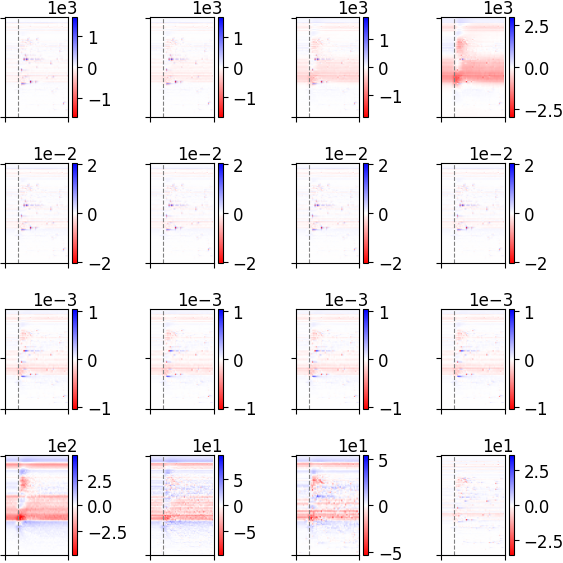

In [203]:
fig, axes = plt.subplots(4,4,figsize=(6,6))
plotFig(axes[0][0],icsd_high_new_200.get_csd())
plotFig(axes[0][1],icsd_high_new_100.get_csd())
plotFig(axes[0][2],icsd_high_new_50.get_csd())
plotFig(axes[0][3],icsd_high_new_20.get_csd())
plotFig(axes[1][0],sCsd_high_new.get_csd())
plotFig(axes[1][1],sCsd_high_new.get_csd())
plotFig(axes[1][2],sCsd_high_new.get_csd())
plotFig(axes[1][3],sCsd_high_new.get_csd())
plotFig(axes[2][0],nncsd.T)
plotFig(axes[2][1],nncsd.T)
plotFig(axes[2][2],nncsd.T)
plotFig(axes[2][3],nncsd.T)
plotFig(axes[3][0],ocsd_200.T)
plotFig(axes[3][1],ocsd_100.T)
plotFig(axes[3][2],ocsd_50.T)
plotFig(axes[3][3],ocsd_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii.png',dpi=600)

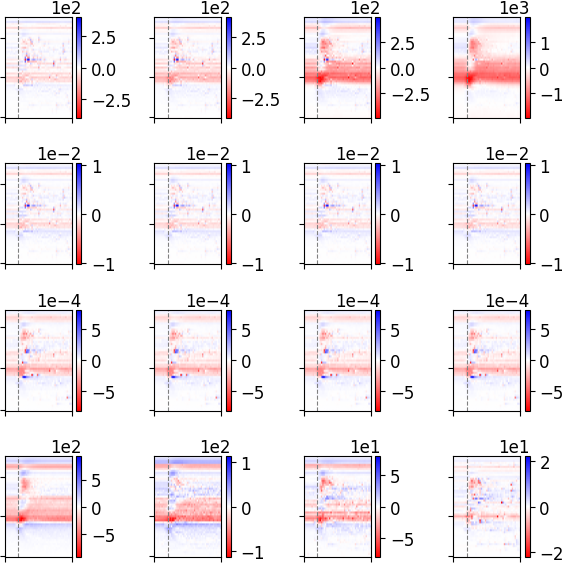

In [241]:
fig, axes = plt.subplots(4,4,figsize=(6,6))
plotFig(axes[0][0],icsd_low_new_200.get_csd())
plotFig(axes[0][1],icsd_low_new_100.get_csd())
plotFig(axes[0][2],icsd_low_new_50.get_csd())
plotFig(axes[0][3],icsd_low_new_20.get_csd())
plotFig(axes[1][0],sCsd_low_new.get_csd())
plotFig(axes[1][1],sCsd_low_new.get_csd())
plotFig(axes[1][2],sCsd_low_new.get_csd())
plotFig(axes[1][3],sCsd_low_new.get_csd())
plotFig(axes[2][0],nncsd_low.T)
plotFig(axes[2][1],nncsd_low.T)
plotFig(axes[2][2],nncsd_low.T)
plotFig(axes[2][3],nncsd_low.T)
plotFig(axes[3][0],ocsd_low_200.T)
plotFig(axes[3][1],ocsd_low_100.T)
plotFig(axes[3][2],ocsd_low_50.T)
plotFig(axes[3][3],ocsd_low_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

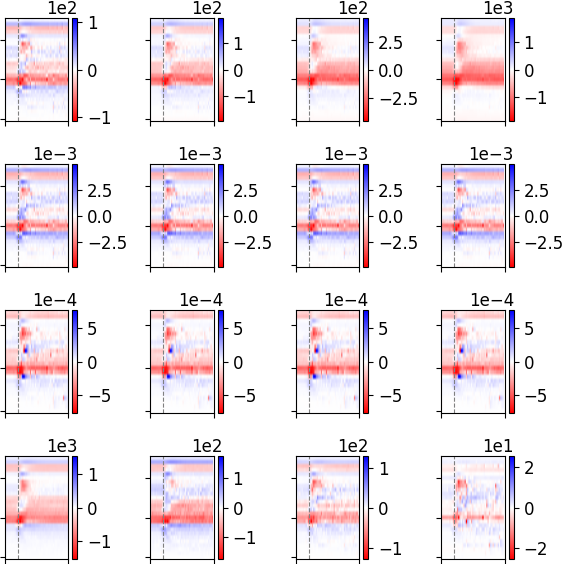

In [246]:
fig, axes = plt.subplots(4,4,figsize=(6,6))
plotFig(axes[0][0],icsd_half_new_200.get_csd())
plotFig(axes[0][1],icsd_half_new_100.get_csd())
plotFig(axes[0][2],icsd_half_new_50.get_csd())
plotFig(axes[0][3],icsd_half_new_20.get_csd())
plotFig(axes[1][0],sCsd_half_new.get_csd())
plotFig(axes[1][1],sCsd_half_new.get_csd())
plotFig(axes[1][2],sCsd_half_new.get_csd())
plotFig(axes[1][3],sCsd_half_new.get_csd())
plotFig(axes[2][0],nncsd_half.T)
plotFig(axes[2][1],nncsd_half.T)
plotFig(axes[2][2],nncsd_half.T)
plotFig(axes[2][3],nncsd_half.T)
plotFig(axes[3][0],ocsd_half_200.T)
plotFig(axes[3][1],ocsd_half_100.T)
plotFig(axes[3][2],ocsd_half_50.T)
plotFig(axes[3][3],ocsd_half_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

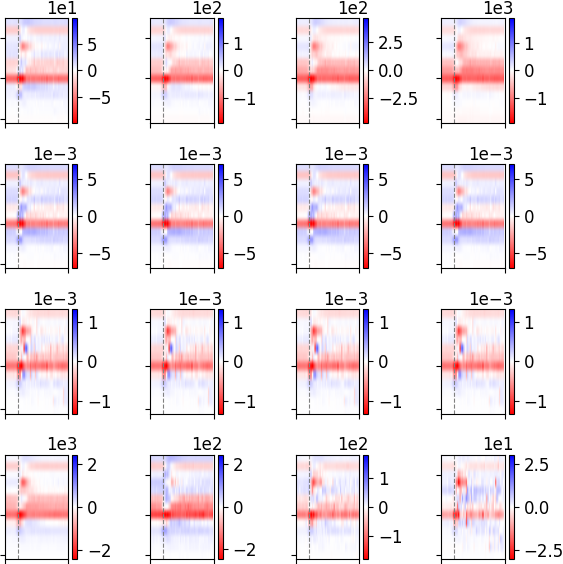

In [250]:
fig, axes = plt.subplots(4,4,figsize=(6,6))
plotFig(axes[0][0],icsd_quarter_new_200.get_csd())
plotFig(axes[0][1],icsd_quarter_new_100.get_csd())
plotFig(axes[0][2],icsd_quarter_new_50.get_csd())
plotFig(axes[0][3],icsd_quarter_new_20.get_csd())
plotFig(axes[1][0],sCsd_quarter_new.get_csd())
plotFig(axes[1][1],sCsd_quarter_new.get_csd())
plotFig(axes[1][2],sCsd_quarter_new.get_csd())
plotFig(axes[1][3],sCsd_quarter_new.get_csd())
plotFig(axes[2][0],nncsd_quarter.T)
plotFig(axes[2][1],nncsd_quarter.T)
plotFig(axes[2][2],nncsd_quarter.T)
plotFig(axes[2][3],nncsd_quarter.T)
plotFig(axes[3][0],ocsd_quarter_200.T)
plotFig(axes[3][1],ocsd_quarter_100.T)
plotFig(axes[3][2],ocsd_quarter_50.T)
plotFig(axes[3][3],ocsd_quarter_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

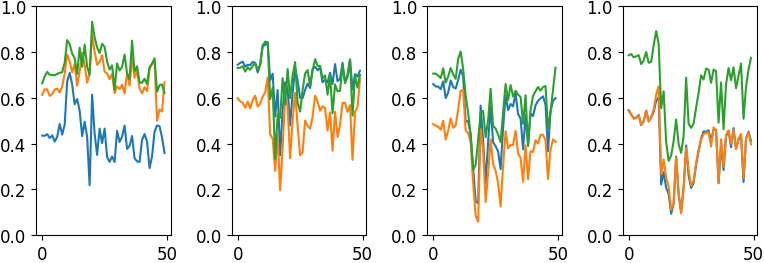

In [155]:
%matplotlib inline

plt.figure(figsize=(8,3))
plt.subplot(141)
plt.plot(correlations_test_20)
plt.plot(correlations_test_std_20)
plt.plot(correlations_test_nn_20)
plt.ylim([0,1])

plt.subplot(142)
plt.plot(correlations_test_50)
plt.plot(correlations_test_std_50)
plt.plot(correlations_test_nn_50)
plt.ylim([0,1])

plt.subplot(143)
plt.plot(correlations_test_100)
plt.plot(correlations_test_std_100)
plt.plot(correlations_test_nn_100)
plt.ylim([0,1])

plt.subplot(144)
plt.plot(correlations_test_200)
plt.plot(correlations_test_std_200)
plt.plot(correlations_test_nn_200)
plt.ylim([0,1])

plt.tight_layout()


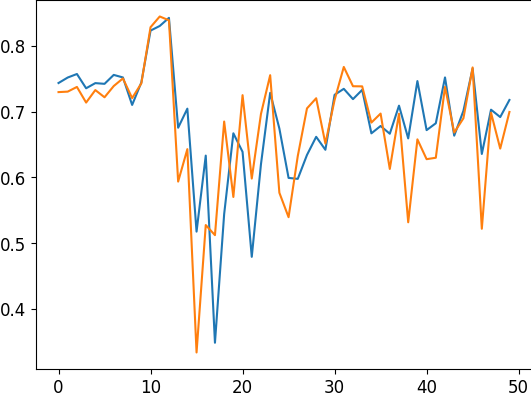

In [156]:
plt.figure()
plt.plot(correlations_test_50)
plt.plot(correlations_test_nn_50)


In [158]:
np.mean(correlations_test_nn_50)

np.float64(0.6766137467742694)

In [45]:
print(np.mean(correlations_test_50))
print(np.mean(correlations_test_nn_50))

print(np.mean(correlations_test_100))
print(np.mean(correlations_test_nn_100))

0.686588326470828
0.6766137467742694
0.5191391388438961
0.588329073017437


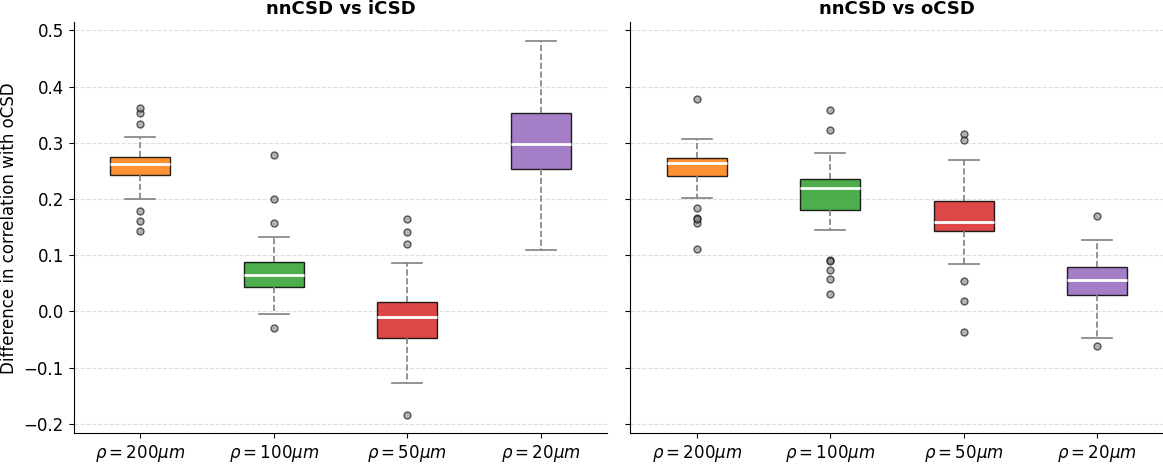

In [37]:
differences_icsd = [np.array(correlations_test_nn_200)-np.array(correlations_test_200), np.array(correlations_test_nn_100)-np.array(correlations_test_100), np.array(correlations_test_nn_50)-np.array(correlations_test_50), np.array(correlations_test_nn_20)-np.array(correlations_test_20)]
differences_std = [np.array(correlations_test_nn_200)-np.array(correlations_test_std_200), np.array(correlations_test_nn_100)-np.array(correlations_test_std_100), np.array(correlations_test_nn_50)-np.array(correlations_test_std_50), np.array(correlations_test_nn_20)-np.array(correlations_test_std_20)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
colors = ["C1", "C2", "C3", "C4"]
labels = [r"$\rho=200\mu m$", r"$\rho=100\mu m$", r"$\rho=50\mu m$", r"$\rho=20\mu m$"]
for ax, data, title in zip(axes, [differences_icsd, differences_std], ["nnCSD vs iCSD", "nnCSD vs oCSD"]):
    bp = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=labels,
        medianprops=dict(color="white", linewidth=2),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for whisker in bp["whiskers"]:
        whisker.set(color="gray", linewidth=1.2, linestyle="--")
    for cap in bp["caps"]:
        cap.set(color="gray", linewidth=1.2)
    for flier in bp["fliers"]:
        flier.set(marker="o", markerfacecolor="gray", markersize=5, alpha=0.6)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylabel("Difference in correlation with oCSD")
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/whiskerPlots.png',dpi=600)
plt.show()

In [38]:
from scipy import stats

datasets = {"nnCSD vs iCSD": differences_icsd, "nnCSD vs oCSD": differences_std}
rhos = [r"ρ=200μm", r"ρ=100μm", r"ρ=50μm", r"ρ=20μm"]

for dataset_name, data in datasets.items():
    print(f"\n{'='*55}")
    print(f" {dataset_name}")
    print(f"{'='*55}")
    print(f"{'Array':<12} {'Mean':>7} {'t-stat':>8} {'t p-val':>9} {'W-stat':>8} {'W p-val':>9}")
    print(f"{'-'*55}")
    for label, arr in zip(rhos, data):
        t_stat, t_pval = stats.ttest_1samp(arr, popmean=0)
        w_stat, w_pval = stats.wilcoxon(arr)
        print(f"{label:<12} {arr.mean():>7.4f} {t_stat:>8.3f} {t_pval:>9.4f} {w_stat:>8.1f} {w_pval:>9.4f}")


 nnCSD vs iCSD
Array           Mean   t-stat   t p-val   W-stat   W p-val
-------------------------------------------------------
ρ=200μm       0.2589   46.132    0.0000      0.0    0.0000
ρ=100μm       0.0692    9.370    0.0000     17.0    0.0000
ρ=50μm       -0.0100   -1.077    0.2869    498.0    0.1813
ρ=20μm        0.3011   23.880    0.0000      0.0    0.0000

 nnCSD vs oCSD
Array           Mean   t-stat   t p-val   W-stat   W p-val
-------------------------------------------------------
ρ=200μm       0.2527   41.708    0.0000      0.0    0.0000
ρ=100μm       0.2071   23.928    0.0000      0.0    0.0000
ρ=50μm        0.1633   18.357    0.0000      2.0    0.0000
ρ=20μm        0.0548    9.191    0.0000     49.0    0.0000


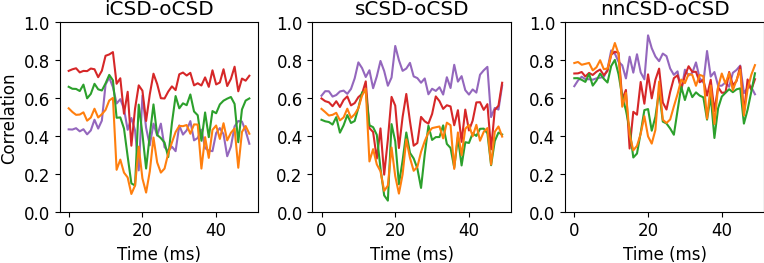

In [41]:
plt.figure(figsize=(8,3))
plt.subplot(131)
plt.title('iCSD-oCSD')
plt.plot(correlations_test_20,c='C4')
plt.plot(correlations_test_50,c='C3')
plt.plot(correlations_test_100,c='C2')
plt.plot(correlations_test_200,c='C1')
# plt.plot(correlations_test_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.ylim([0,1])

plt.subplot(132)
plt.title('sCSD-oCSD')
plt.plot(correlations_test_std_20,c='C4')
plt.plot(correlations_test_std_50,c='C3')
plt.plot(correlations_test_std_100,c='C2')
plt.plot(correlations_test_std_200,c='C1')
# plt.plot(correlations_test_std_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylim([0,1])

plt.subplot(133)
plt.title('nnCSD-oCSD')
plt.plot(correlations_test_nn_20,c='C4')
plt.plot(correlations_test_nn_50,c='C3')
plt.plot(correlations_test_nn_100,c='C2')
plt.plot(correlations_test_nn_200,c='C1')
# plt.plot(correlations_test_nn_500,c='C0')
plt.ylim([0,1])
# plt.legend([r'$\rho=200 \mu m$',r'$\rho=100 \mu m$',r'$\rho=50 \mu m$',r'$\rho=20 \mu m$'])
plt.xlabel('Time (ms)')

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii_correlation.png',dpi=600)


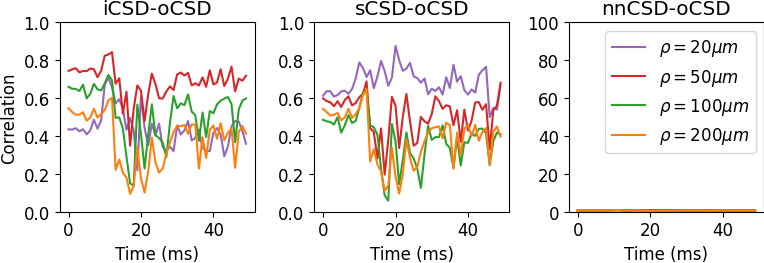

In [42]:
plt.figure(figsize=(8,3))
plt.subplot(131)
plt.title('iCSD-oCSD')
plt.plot(correlations_test_20,c='C4')
plt.plot(correlations_test_50,c='C3')
plt.plot(correlations_test_100,c='C2')
plt.plot(correlations_test_200,c='C1')
# plt.plot(correlations_test_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.ylim([0,1])

plt.subplot(132)
plt.title('sCSD-oCSD')
plt.plot(correlations_test_std_20,c='C4')
plt.plot(correlations_test_std_50,c='C3')
plt.plot(correlations_test_std_100,c='C2')
plt.plot(correlations_test_std_200,c='C1')
# plt.plot(correlations_test_std_500,c='C0')
plt.xlabel('Time (ms)')
plt.ylim([0,1])

plt.subplot(133)
plt.title('nnCSD-oCSD')
plt.plot(correlations_test_nn_20,c='C4')
plt.plot(correlations_test_nn_50,c='C3')
plt.plot(correlations_test_nn_100,c='C2')
plt.plot(correlations_test_nn_200,c='C1')
# plt.plot(correlations_test_nn_500,c='C0')
plt.ylim([0,100])
plt.legend([r'$\rho=20 \mu m$',r'$\rho=50 \mu m$',r'$\rho=100 \mu m$',r'$\rho=200 \mu m$'])
plt.xlabel('Time (ms)')

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii_correlation_legend.png',dpi=600)

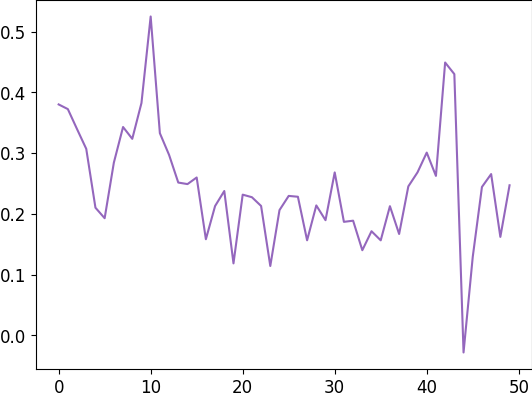

In [30]:
plt.figure()
plt.plot(correlations_test_20,c='C4')

In [31]:
np.mean(correlations_test_20)

np.float64(0.24512363226574382)

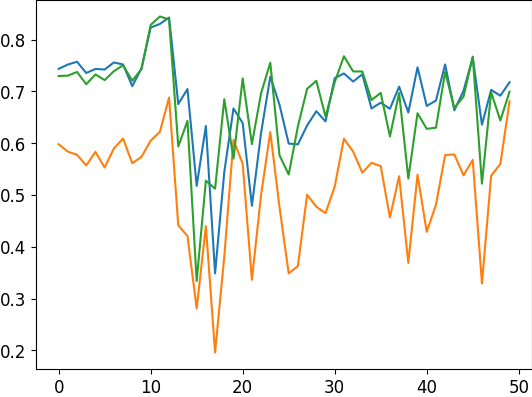

In [27]:
plt.figure()
plt.plot(correlations_test_50)
plt.plot(correlations_test_std_50)
plt.plot(correlations_test_nn_50)

In [11]:
def getMeanCorrelation(icsd,ocsd):

    from scipy.stats import wasserstein_distance

    correlations = []
    distances = []
    icsdVal = icsd.get_csd()

    rms = np.mean(np.sqrt(icsdVal**2))

    icsdVal /=  rms

    rms = np.mean(np.sqrt(ocsd**2))

    ocsd /= rms

    for i in range(icsdVal.shape[1]):
        distances.append(wasserstein_distance(icsdVal[:,i],ocsd.T[:,i]))
        correlations.append(np.corrcoef(icsdVal[:,i],ocsd.T[:,i])[0,1])

    return np.mean(correlations), np.mean(distances)

In [12]:
def producePlotAndCorrelation(icsd,ocsd,icsdL4,ocsdL4,icsdL5,ocsdL5):

    fig, axes = plt.subplots(2,3,figsize=(6,4))

    plotFig(axes[0][0],icsd.get_csd())
    plotFig(axes[1][0],ocsd.T)
    
    plotFig(axes[0][1],icsdL4.get_csd())
    plotFig(axes[1][1],ocsdL4.T)
    
    plotFig(axes[0][2],icsdL5.get_csd())
    plotFig(axes[1][2],ocsdL5.T)

    correlations = [getMeanCorrelation(icsd,ocsd)[0],getMeanCorrelation(icsdL4,ocsdL4)[0],getMeanCorrelation(icsdL5,ocsdL5)[0]]
    distances = [getMeanCorrelation(icsd,ocsd)[1],getMeanCorrelation(icsdL4,ocsdL4)[1],getMeanCorrelation(icsdL5,ocsdL5)[1]]

    return correlations, distances

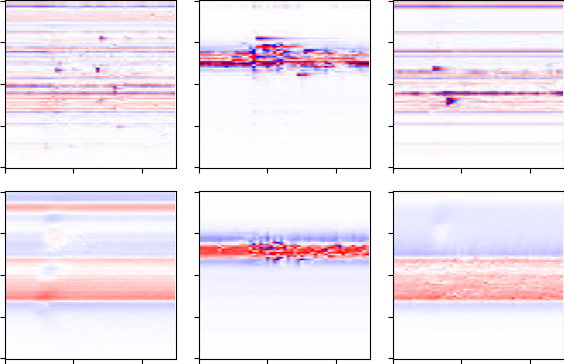

In [13]:
correlationsOrig500, distancesOrig500 = producePlotAndCorrelation(icsd_high_original_500,ocsd_original_500,icsd_L4_original_500,ocsd_l4_500,icsd_L5_original_500,ocsd_l5_500)


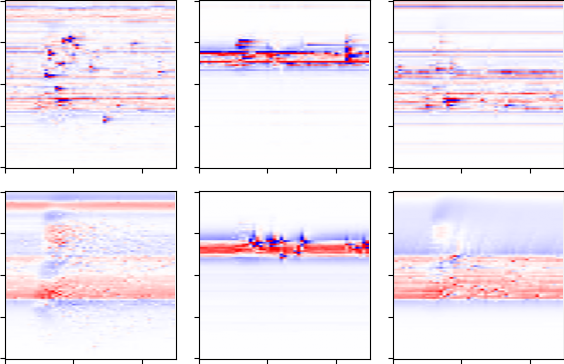

In [14]:
correlationsNoRecurrent500, distancesNoRecurrent500 = producePlotAndCorrelation(icsd_high_noRecurrent_500,ocsd_noRecurrent_500,icsd_L4_noRecurrent_500,ocsd_noRecurrent_l4_500,icsd_L5_noRecurrent_500,ocsd_noRecurrent_l5_500)


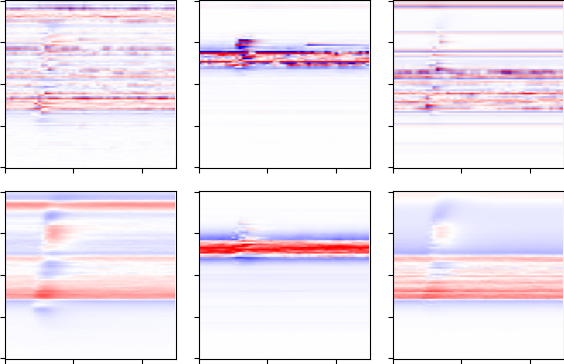

In [15]:
correlationsNoActive500, distancesNoActive500 = producePlotAndCorrelation(icsd_high_NoActive_500,ocsd_noActive_500,icsd_L4_NoActive_500,ocsd_noActive_l4_500,icsd_L5_NoActive_500,ocsd_noActive_l5_500)


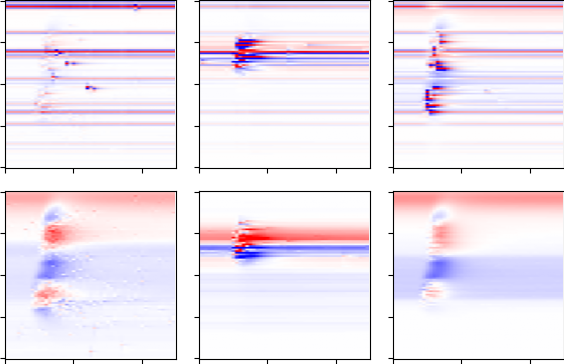

In [16]:
correlationsNoNoise500, distancesNoNoise500 = producePlotAndCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500,icsd_L4_NoNoise_500,ocsd_noNoise_l4_500,icsd_L5_NoNoise_500,ocsd_noNoise_l5_500)


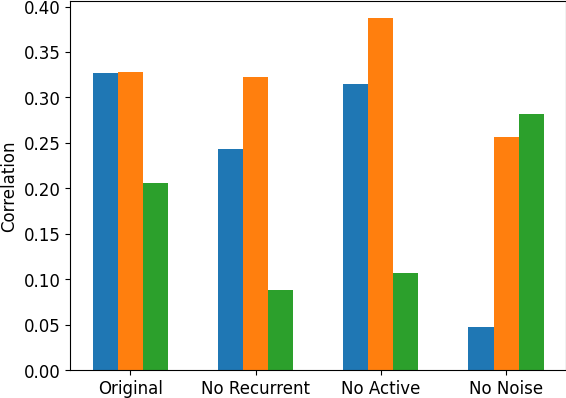

In [28]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations500[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

In [ ]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

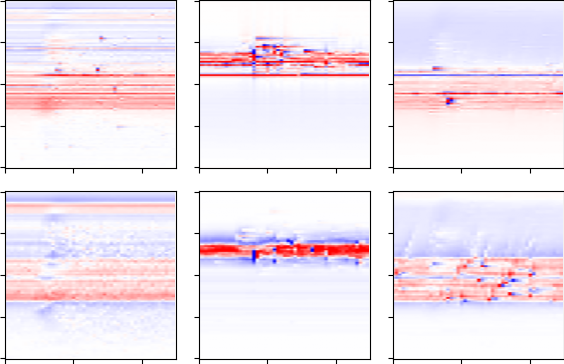

In [19]:
correlationsOrig100, distancesOrig100 = producePlotAndCorrelation(icsd_high_original_100,ocsd_original_100,icsd_L4_original_100,ocsd_l4_100,icsd_L5_original_100,ocsd_l5_100)


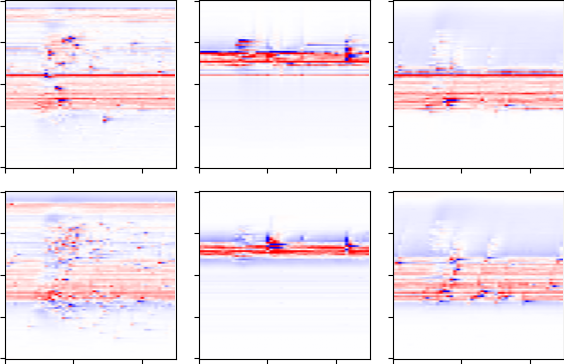

In [20]:
correlationsNoRecurrent100, distancesNoRecurrent100 = producePlotAndCorrelation(icsd_high_noRecurrent_100,ocsd_noRecurrent_100,icsd_L4_noRecurrent_100,ocsd_noRecurrent_l4_100,icsd_L5_noRecurrent_100,ocsd_noRecurrent_l5_100)


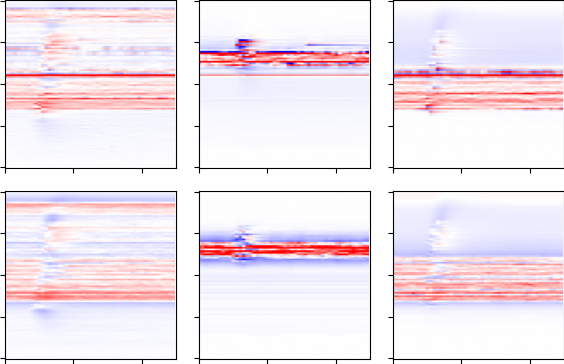

In [21]:
correlationsNoActive100, distancesNoActive100 = producePlotAndCorrelation(icsd_high_NoActive_100,ocsd_noActive_100,icsd_L4_NoActive_100,ocsd_noActive_l4_100,icsd_L5_NoActive_100,ocsd_noActive_l5_100)


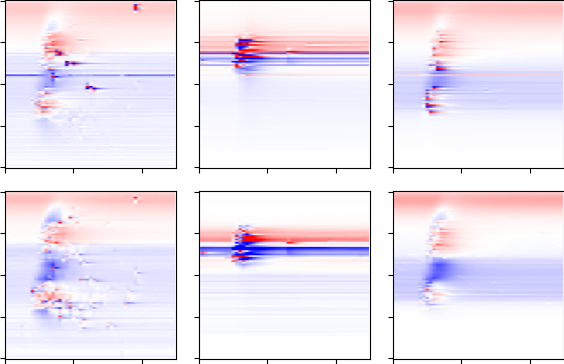

In [22]:
correlationsNoNoise100, distancesNoNoise100 = producePlotAndCorrelation(icsd_high_NoNoise_100,ocsd_noNoise_100,icsd_L4_NoNoise_100,ocsd_noNoise_l4_100,icsd_L5_NoNoise_100,ocsd_noNoise_l5_100)


PermissionError: [Errno 13] Permission denied: '/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/explainPriorWork.png'

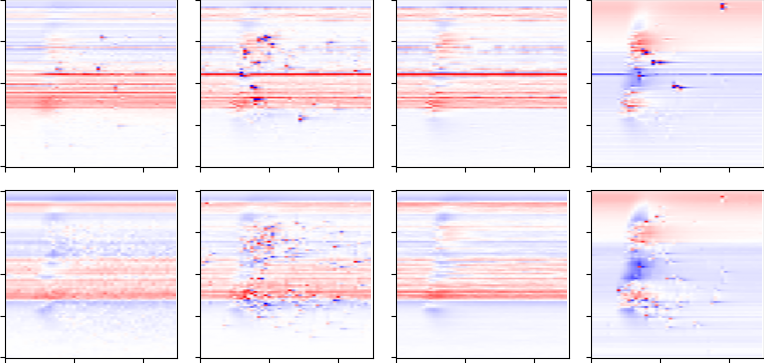

In [29]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_high_original_100.get_csd())
plotFig(axes[1][0],ocsd_original_100.T)

plotFig(axes[0][1],icsd_high_noRecurrent_100.get_csd())
plotFig(axes[1][1],ocsd_noRecurrent_100.T)

plotFig(axes[0][2],icsd_high_NoActive_100.get_csd())
plotFig(axes[1][2],ocsd_noActive_100.T)

plotFig(axes[0][3],icsd_high_NoNoise_100.get_csd())
plotFig(axes[1][3],ocsd_noNoise_100.T)

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/explainPriorWork.png',dpi=600)


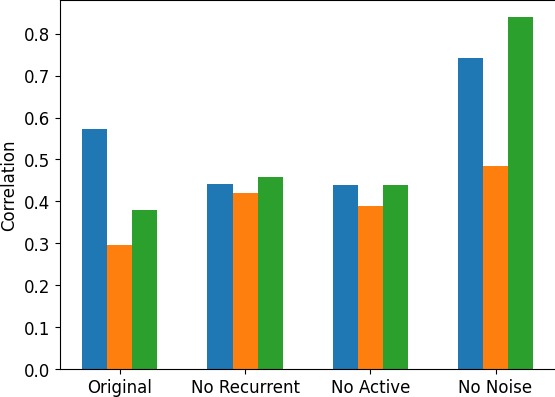

In [47]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

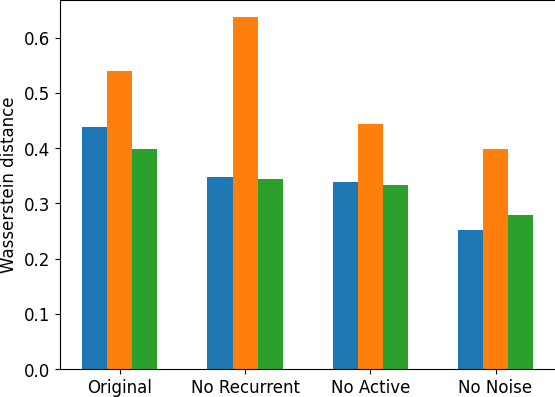

In [48]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, distances100[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Wasserstein distance')

plt.show()

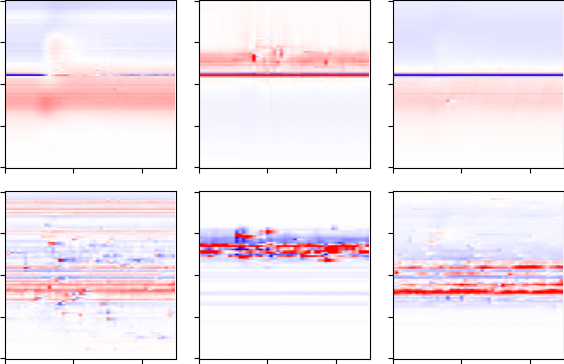

In [23]:
correlationsOrig20, distancesOrig20 = producePlotAndCorrelation(icsd_high_original_20,ocsd_original_20,icsd_L4_original_20,ocsd_l4_20,icsd_L5_original_20,ocsd_l5_20)


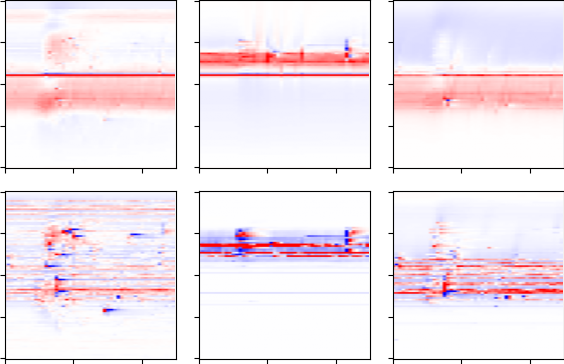

In [24]:
correlationsNoRecurrent20, distancesNoRecurrent20 = producePlotAndCorrelation(icsd_high_noRecurrent_20,ocsd_noRecurrent_20,icsd_L4_noRecurrent_20,ocsd_noRecurrent_l4_20,icsd_L5_noRecurrent_20,ocsd_noRecurrent_l5_20)


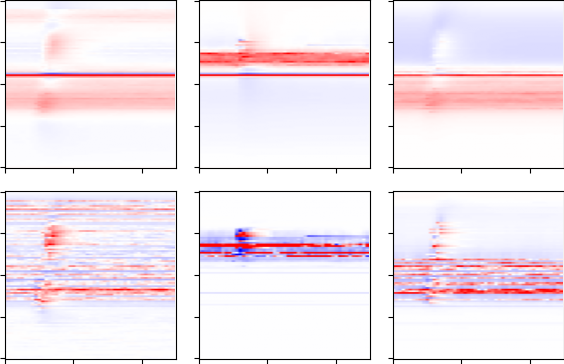

In [25]:
correlationsNoActive20, distancesNoActive20 = producePlotAndCorrelation(icsd_high_NoActive_20,ocsd_noActive_20,icsd_L4_NoActive_20,ocsd_noActive_l4_20,icsd_L5_NoActive_20,ocsd_noActive_l5_20)



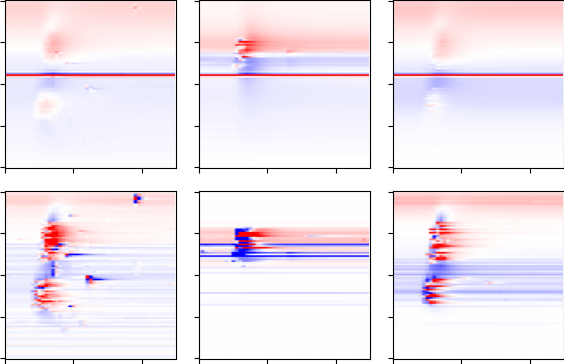

In [26]:
correlationsNoNoise20, distancesNoNoise20 = producePlotAndCorrelation(icsd_high_NoNoise_20,ocsd_noNoise_20,icsd_L4_NoNoise_20,ocsd_noNoise_l4_20,icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)


In [27]:
correlations500 = np.array([correlationsOrig500, correlationsNoRecurrent500, correlationsNoActive500, correlationsNoNoise500])
correlations100 = np.array([correlationsOrig100, correlationsNoRecurrent100, correlationsNoActive100, correlationsNoNoise100])
correlations20 = np.array([correlationsOrig20, correlationsNoRecurrent20, correlationsNoActive20, correlationsNoNoise20])

distances500 = np.array([distancesOrig500, distancesNoRecurrent500, distancesNoActive500, distancesNoNoise500])
distances100 = np.array([distancesOrig100, distancesNoRecurrent100, distancesNoActive100, distancesNoNoise100])
distances20 = np.array([distancesOrig20, distancesNoRecurrent20, distancesNoActive20, distancesNoNoise20])


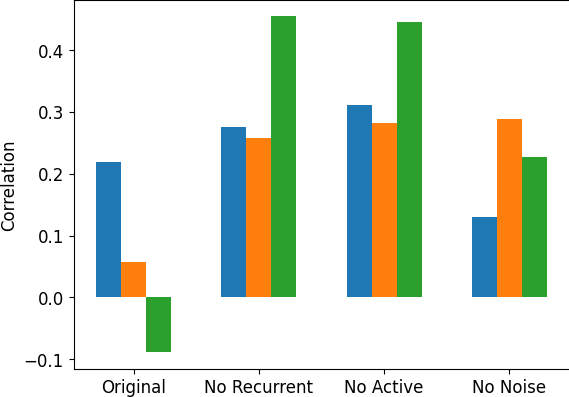

In [35]:
bar_width = 0.2
x = np.arange(4)

fig, ax = plt.subplots()

for i in range(3):
    ax.bar(x + i*bar_width, correlations20[:, i], width=bar_width)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(['Original','No Recurrent','No Active','No Noise'])

plt.ylabel('Correlation')

plt.show()

In [28]:
for f in correlations500:
    print(f)

[np.float64(0.2752671015621234), np.float64(0.3284058440580628), np.float64(0.20644730077464055)]
[np.float64(0.24354113253593698), np.float64(0.32260586930556967), np.float64(0.0880944185359527)]
[np.float64(0.24354113253593698), np.float64(0.38710142215979104), np.float64(0.10673677708919849)]
[np.float64(0.047728169403724416), np.float64(0.25602402211449593), np.float64(0.2814694035179071)]


In [29]:
for f in correlations20:
    print(f)

[np.float64(0.21891397057664397), np.float64(0.05664435362826472), np.float64(-0.08915088554564925)]
[np.float64(0.27614694674365237), np.float64(0.25849949703259484), np.float64(0.4547790912642513)]
[np.float64(0.31219379218221016), np.float64(0.2826921516221745), np.float64(0.4461597521575362)]
[np.float64(0.1301064764045144), np.float64(0.2881474621050847), np.float64(0.22661532839109277)]


In [30]:
for f in distances20:
    print(f)

[np.float64(0.5488986452327381), np.float64(0.9883529054511604), np.float64(0.8842026219278981)]
[np.float64(0.6761325566431411), np.float64(0.9194639740296217), np.float64(0.6229058859282423)]
[np.float64(0.6864241820119155), np.float64(0.9037705480001875), np.float64(0.608288553514378)]
[np.float64(0.7389762257339878), np.float64(1.007470140901826), np.float64(0.6167189239219502)]


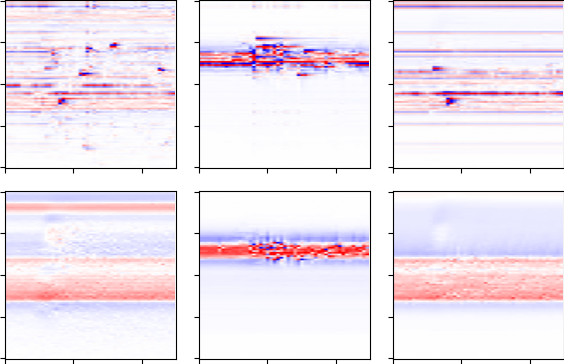

In [92]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_original_500.get_csd())
plotFig(axes[1][0],ocsd_original_500.T)

plotFig(axes[0][1],icsd_L4_original_500.get_csd())
plotFig(axes[1][1],ocsd_l4_500.T)

plotFig(axes[0][2],icsd_L5_original_500.get_csd())
plotFig(axes[1][2],ocsd_l5_500.T)



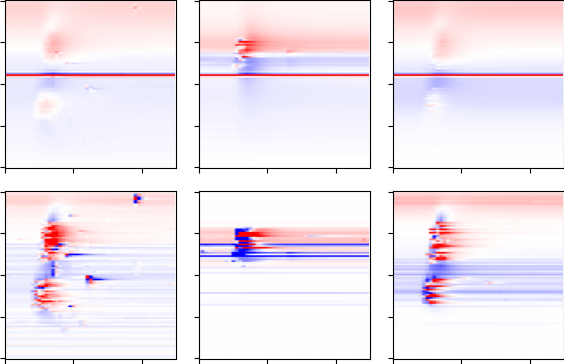

In [78]:
fig, axes = plt.subplots(2,3,figsize=(6,4))

plotFig(axes[0][0],icsd_high_NoNoise_20.get_csd())
plotFig(axes[1][0],ocsd_noNoise_20.T)

plotFig(axes[0][1],icsd_L4_NoNoise_20.get_csd())
plotFig(axes[1][1],ocsd_noNoise_l4_20.T)

plotFig(axes[0][2],icsd_L5_NoNoise_20.get_csd())
plotFig(axes[1][2],ocsd_noNoise_l5_20.T)

In [114]:
ocsd_noNoise_l4_20.T.shape

(101, 50)

In [84]:
getMeanCorrelation(icsd_L4_NoNoise_20,ocsd_noNoise_l4_20)

np.float64(0.6440737308366242)

In [85]:
getMeanCorrelation(icsd_L5_NoNoise_20,ocsd_noNoise_l5_20)

np.float64(0.6133076645043712)

In [115]:
getMeanCorrelation(icsd_high_NoNoise_500,ocsd_noNoise_500)

np.float64(0.5238640841478382)

In [20]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_stim = []
correlations_low_stim = []
correlations_low_half_stim = []
correlations_low_quarter_stim = []

for i in np.arange(1500,1550):
    correlations_high_stim.append(np.corrcoef(icsd_high.get_csd()[:,i],objective_disk_full_highRes.T[:,i])[0,1])
    correlations_low_stim.append(np.corrcoef(icsd_low.get_csd()[:,i],objective_disk_full_lowRes.T[:,i])[0,1])
    correlations_low_half_stim.append(np.corrcoef(icsd_low_half.get_csd()[:,i],objective_disk_half_lowRes.T[:,i])[0,1])
    correlations_low_quarter_stim.append(np.corrcoef(icsd_low_quarter.get_csd()[:,i],objective_disk_quarter_lowRes.T[:,i])[0,1])


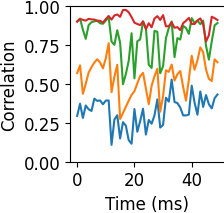

In [21]:
### Plots Figure 2b

plt.figure(figsize=(2.5,2.5))
plt.plot(correlations_high_stim,c='C0')
plt.plot(correlations_low_stim,c='C1')
plt.plot(correlations_low_half_stim,c='C2')
plt.plot(correlations_low_quarter_stim,c='C3')

plt.ylim([0,1])
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
# plt.savefig('figures/correlations.png',dpi=300)

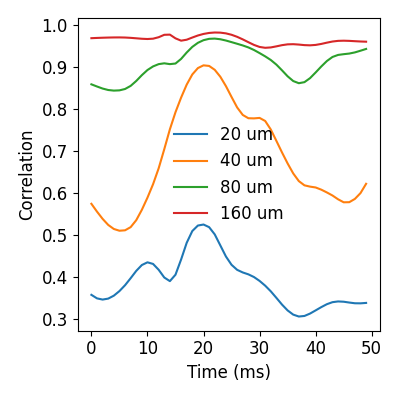

In [25]:
### Plots Figure 2b again, but with a legend

plt.figure(figsize=(4,4))
plt.plot(correlations_high_stim,c='C0',linestyle=None)
plt.plot(correlations_low_stim,c='C1',linestyle=None)
plt.plot(correlations_low_half_stim,c='C2',linestyle=None)
plt.plot(correlations_low_quarter_stim,c='C3',linestyle=None)

# plt.plot(correlations_high_rest,'--',c='C0')
# plt.plot(correlations_low_rest,'--',c='C1')
# plt.plot(correlations_low_half_rest,'--',c='C2')
# plt.plot(correlations_low_quarter_rest,'--',c='C3')

plt.legend(['20 um', '40 um','80 um','160 um'],framealpha=0)
plt.xlabel('Time (ms)')
plt.ylabel('Correlation')
plt.tight_layout()
plt.savefig('figures/correlations_legend.png',dpi=300)